# 1.1 線形モデル（4/4）頑健な回帰と拡張

**原典**: scikit-learn User Guide [1.1. Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) の 1.1.14〜1.1.16（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・外れ値の種類（X 方向 / y 方向、小さい / 大きい）を区別できる<br>・RANSAC / Theil-Sen / Huber を、状況に応じて選べる<br>・平均ではなく「分位点」を予測して、予測区間を作れる<br>・線形モデルで曲線を当てはめる方法（多項式特徴）を知る |
| **前提** | [1/4 最小二乗法と正則化](./01_linear_models_1_ols_regularization.ipynb)（残差、二乗誤差） |
| **目安時間** | 45〜60 分 |

記号の意味は 1/4 と同じです（📖 ガイドの解説 / 💡 補足 / 📚 用語 / 🔢 数式を読む / 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史 / 🧪 やってみよう / 📈 学習したモデルを見る / 👀 結果の読み方 / ⚠️ つまずきポイント）。

### 目次

1. 1.1.14 ロバスト回帰: 外れ値とモデルの誤り
2. 1.1.15 分位点回帰
3. 1.1.16 多項式回帰: 基底関数で線形モデルを拡張する
4. 1.1 全体のまとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import PolynomialFeatures

def slope_of(model):
    # RANSAC は内部の推定器 estimator_ に係数を持つ
    return model.estimator_.coef_[0] if hasattr(model, "estimator_") else model.coef_[0]

---
## 1. ロバスト回帰（1.1.14 Robustness regression: outliers and modeling errors）

**ねらい**: 外れ値に引きずられない回帰の方法を知り、外れ値の種類に応じて使い分けられるようになる。

### 💡 補足: 最小二乗法はなぜ外れ値に弱いのか

1/4 で見たように、最小二乗法は残差を**二乗**します。残差 10 の点は、残差 1 の点の **100 倍**の影響を持ちます。たった数個の大きく外れた点（測定ミスや入力ミス）が、直線全体を自分の方へ引き寄せてしまうのです。

### 📖 ガイドの解説

ロバスト回帰の目的は、**壊れたデータ**があっても回帰モデルを当てはめることです。壊れ方には、外れ値（outlier）がある場合と、モデルそのものに誤りがある場合があります。

> 📚 **用語**
> - **ロバスト（robust）/ 頑健**: 想定外のデータ（外れ値など）が混ざっても、結果が大きく崩れない性質。
> - **外れ値（outlier）/ 内れ値（inlier）**: ほかのデータの傾向から大きく外れた点 / 傾向に沿ったふつうの点。
> - **モデルの誤り（modeling error）**: データの本当の関係が、仮定したモデル（例: 直線）と違うこと。
> - **高レバレッジ点**: 特徴の値がほかから遠く離れた点。てこの原理のように、直線の傾きを大きく動かす力を持つ（実験 ② で扱います）。

### 🎯 なぜ使うのか

現実のデータには、入力ミス、センサーの故障、単位の取り違え、ごく一部の特殊なケースなどが必ず混ざります。外れ値を 1 件ずつ見つけて取り除くのは手間がかかり、見落としもあります。ロバスト回帰は、**外れ値の影響を自動的に小さくして**、大多数のデータが示す傾向を捉えます。

### 1.1.14.1 さまざまな状況と、役に立つ概念

📖 外れ値を含むデータを扱うときは、次の点に注意します。

**外れ値は X 方向か、y 方向か**

- y 方向の外れ値: 入力はふつうだが、目的変数の値がおかしい（例: 家賃の入力ミスで 1 桁多い）
- X 方向の外れ値: 入力（特徴）の値が、ほかのデータから遠く離れている（例: 面積 5000 m² の物件が紛れ込む）

**外れ値の割合と、誤差の大きさ**

外れ値の**個数**も大事ですが、**どれだけ外れているか**も大事です（小さな外れ値 / 大きな外れ値）。

**破綻点（breakdown point）**: ロバストな当てはめで重要な概念です。当てはめが正常なデータ（内れ値）を捉えられなくなるまでに、許容できる外れ値の**割合**を指します。

なお一般に、高次元（特徴数が多い）でのロバストな当てはめは非常に難しく、ここで紹介するモデルはそうした設定ではおそらくうまく働きません。

### 📖 どの推定器を選ぶか（トレードオフ）

scikit-learn にはロバスト回帰の推定器が 3 つあります: **RANSAC**、**Theil-Sen**、**HuberRegressor**。

- `HuberRegressor` は、サンプル数が非常に多い（`n_samples >> n_features`）場合を除き、RANSAC や Theil-Sen より速いはずです。RANSAC と Theil-Sen はデータの一部分に当てはめる方式だからです。ただし既定のパラメータでは、RANSAC と Theil-Sen は `HuberRegressor` ほど頑健ではない可能性があります。
- RANSAC は Theil-Sen より速く、サンプル数が増えてもずっとよくスケールします。
- RANSAC は、**y 方向の大きな外れ値**（最もよくある状況）にうまく対処します。
- Theil-Sen は、**X 方向の中程度の外れ値**にうまく対処します。ただしこの性質は高次元では失われます。

**迷ったら RANSAC を使いましょう。**

### 🧪 やってみよう ①: y 方向の大きな外れ値

真の傾きが 2.0 の直線データ 100 点のうち、15 点の y に +15〜+30 の大きな外れ値を足します。

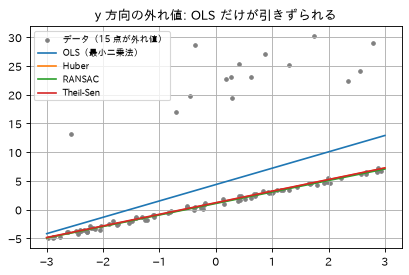

,推定した傾き（真の値 2.0）
OLS（最小二乗法）,2.8481
Huber,2.0252
RANSAC,1.9996
Theil-Sen,2.0198


In [2]:
rng = np.random.RandomState(0)
x = rng.uniform(-3, 3, 100)
y = 2 * x + 1 + 0.3 * rng.randn(100)
y[:15] += rng.uniform(15, 30, 15)          # 15% を y 方向の大きな外れ値にする
X = x[:, None]

models = {
    "OLS（最小二乗法）": lm.LinearRegression(),
    "Huber": lm.HuberRegressor(),
    "RANSAC": lm.RANSACRegressor(random_state=0),
    "Theil-Sen": lm.TheilSenRegressor(random_state=0),
}
for m in models.values():
    m.fit(X, y)

grid = np.linspace(-3, 3, 50)[:, None]
plt.scatter(x, y, s=10, c="gray", label="データ（15 点が外れ値）")
for name, m in models.items():
    plt.plot(grid, m.predict(grid), label=name)
plt.legend(fontsize=8); plt.title("y 方向の外れ値: OLS だけが引きずられる"); plt.show()

pd.Series({name: slope_of(m) for name, m in models.items()}, name="推定した傾き（真の値 2.0）").to_frame()

### 👀 結果の読み方

- OLS の直線は、上にある外れ値の方へ持ち上げられ、傾きも真の値からずれました。
- Huber・RANSAC・Theil-Sen の 3 つは、ほぼ真の直線を捉えています。

### 🧪 やってみよう ②: X 方向の外れ値（高レバレッジ点）

今度は、一部の点の **x を遠くに**移します（y はそのまま）。直線から遠い位置にある点は、てこのように直線を大きく傾ける力を持ちます（**高レバレッジ点**）。外れ値の割合と距離を変えて、傾きの誤差（|推定値 − 2|、5 回の平均）を比べます。

In [3]:
results = {}
for frac in [0.05, 0.1, 0.2]:
    for x_far in [4, 8]:
        errors = {}
        for seed in range(5):
            r = np.random.RandomState(seed)
            xs = r.uniform(-2, 2, 200)
            ys = 2 * xs + 1 + 0.3 * r.randn(200)
            k = int(frac * 200)
            xs[:k] = x_far + 0.3 * r.randn(k)      # x だけを遠くに移す（y は元の値のまま）
            for name, make in [("OLS（最小二乗法）", lm.LinearRegression), ("Huber", lm.HuberRegressor),
                               ("RANSAC", lambda: lm.RANSACRegressor(random_state=0)),
                               ("Theil-Sen", lambda: lm.TheilSenRegressor(random_state=0))]:
                errors.setdefault(name, []).append(abs(slope_of(make().fit(xs[:, None], ys)) - 2))
        results[f"{int(frac * 100)}% / x≈{x_far}"] = {k: np.mean(v) for k, v in errors.items()}
pd.DataFrame(results).rename_axis("外れ値の割合 / 位置 →")

,5% / x≈4,5% / x≈8,10% / x≈4,10% / x≈8,20% / x≈4,20% / x≈8
外れ値の割合 / 位置 →,,,,,,
OLS（最小二乗法）,0.7848,1.4380,1.1347,1.6830,1.4330,1.8229
Huber,0.0754,0.1629,0.1821,1.4849,1.1576,1.7695
RANSAC,0.0126,0.0126,0.0132,0.0132,0.0340,0.0135
Theil-Sen,0.0424,0.0424,0.0807,0.0807,0.1928,0.1917


#### 📈 学習したモデルを見る

表の数字だけでは分かりにくいので、「外れ値 10%、x≈8」の場合（表の種 0 のデータ）について、各モデルが学習した直線を描きます。

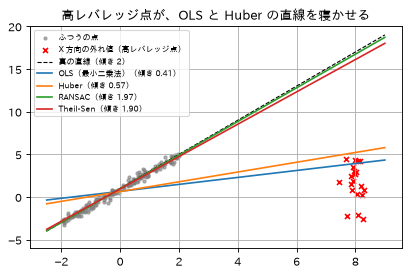

In [4]:
r = np.random.RandomState(0)
xs = r.uniform(-2, 2, 200); ys = 2 * xs + 1 + 0.3 * r.randn(200)
k = int(0.1 * 200); xs[:k] = 8 + 0.3 * r.randn(k)             # 表と同じ作り方
g_l = np.linspace(-2.5, 9, 50)[:, None]
plt.scatter(xs[k:], ys[k:], s=8, c="gray", alpha=0.6, label="ふつうの点")
plt.scatter(xs[:k], ys[:k], s=20, c="red", marker="x", label="X 方向の外れ値（高レバレッジ点）")
plt.plot(g_l, 2 * g_l + 1, "k--", lw=1, label="真の直線（傾き 2）")
for name, m in [("OLS（最小二乗法）", lm.LinearRegression()), ("Huber", lm.HuberRegressor()),
                ("RANSAC", lm.RANSACRegressor(random_state=0)), ("Theil-Sen", lm.TheilSenRegressor(random_state=0))]:
    m.fit(xs[:, None], ys)
    plt.plot(g_l, m.predict(g_l), label=f"{name}（傾き {slope_of(m):.2f}）")
plt.ylim(-6, 20); plt.legend(fontsize=7); plt.title("高レバレッジ点が、OLS と Huber の直線を寝かせる"); plt.show()

👀 赤い × の外れ値は、x が 8 付近と遠くにあるのに、y は元の値（真の直線よりずっと下）のままです。OLS と Huber の直線は、この外れ値の方へ**大きく寝かされ**、ふつうの点（灰色）の傾きとまったく合っていません。直線が外れ値の近くを通るので、外れ値の残差は小さくなり、Huber は「外れ値」と見なせません。RANSAC と Theil-Sen は、灰色の点に沿った真の直線（点線）とほぼ重なっています。

### 👀 結果の読み方（傾きの誤差なので、小さいほど良い）

- **OLS** は、どの条件でも大きく崩れます。
- **Huber は、X 方向の外れ値には強くありません。** 外れ値が少なく近いうちは持ちこたえますが、10% で遠い（x≈8）ときや、20% になると OLS と同じくらい崩れます。
- **Theil-Sen** と **RANSAC** は、どの条件でも頑健でした。この設定では RANSAC のほうがさらに誤差が小さくなりました。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: Huber 損失は「**残差（y 方向のずれ）**が大きい点の影響を弱める」仕組みです。高レバレッジ点は直線を自分の方へ強く引き寄せるので、当てはめた直線からの残差が**小さく見えてしまい**、Huber はそれを外れ値と見抜けません。**X 方向の外れ値が疑われるときは、Huber ではなく RANSAC か Theil-Sen** を使いましょう。

### 🧪 やってみよう ③: ガイドの例「Robust linear estimator fitting」を再現する

ガイドの例と同じ設定です。$y = \sin(x)$ のデータに 3 次多項式を当てはめ、3 点に 1 点を外れ値にして、テストデータでの二乗誤差（小さいほど良い）を比べます。

In [5]:
np.random.seed(42)                                   # ガイドの例と同じ乱数
X_g = np.random.normal(size=400); y_g = np.sin(X_g); X_g = X_g[:, None]
X_test = np.random.normal(size=200); y_test = np.sin(X_test); X_test = X_test[:, None]

scenarios = {}
for label, change in [("X 方向・中程度 (x=3)", ("X", 3)), ("y 方向・中程度 (y=3)", ("y", 3)),
                      ("X 方向・大 (x=10)", ("X", 10)), ("y 方向・大 (y=10)", ("y", 10))]:
    Xc, yc = X_g.copy(), y_g.copy()
    if change[0] == "X": Xc[::3] = change[1]
    else:                yc[::3] = change[1]
    scenarios[label] = {}
    for name, est in [("OLS（最小二乗法）", lm.LinearRegression()), ("Theil-Sen", lm.TheilSenRegressor(random_state=42)),
                      ("RANSAC", lm.RANSACRegressor(random_state=42)), ("Huber", lm.HuberRegressor())]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = make_pipeline(PolynomialFeatures(3), est).fit(Xc, yc)
        scenarios[label][name] = np.mean((m.predict(X_test) - y_test) ** 2)
pd.DataFrame(scenarios).rename_axis("テストの二乗誤差 →")

,X 方向・中程度 (x=3),y 方向・中程度 (y=3),X 方向・大 (x=10),y 方向・大 (y=10)
テストの二乗誤差 →,,,,
OLS（最小二乗法）,0.0031,1.0089,0.0499,11.0552
Theil-Sen,0.0023,0.0339,0.0728,0.2336
RANSAC,0.0027,0.3281,0.0756,0.0020
Huber,0.0023,0.0105,0.0651,0.0105


#### 📈 学習したモデルを見る

ガイドの図と同じように、4 つの状況それぞれで各モデルが学習した曲線（3 次多項式）を描きます。黒い点線が真の関数 $\sin(x)$ です。

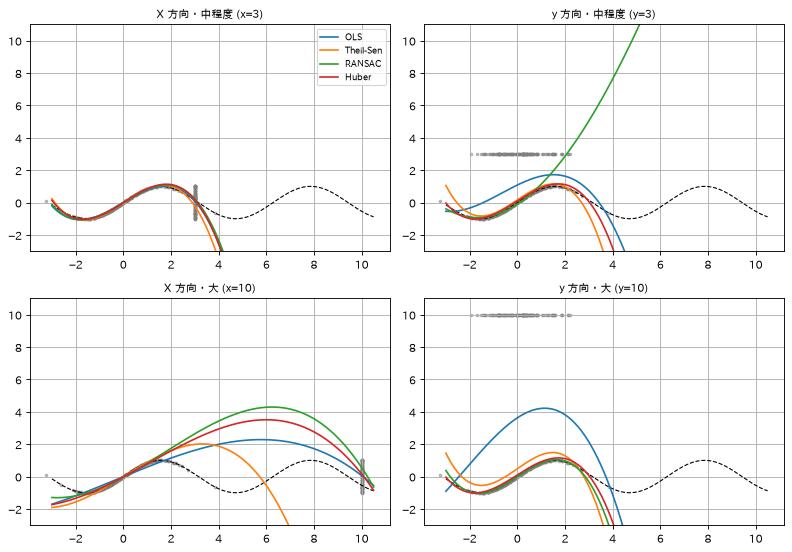

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
g_s = np.linspace(-3, 10.5, 300)[:, None]
for ax, (label, change) in zip(axes.ravel(), [("X 方向・中程度 (x=3)", ("X", 3)), ("y 方向・中程度 (y=3)", ("y", 3)),
                                              ("X 方向・大 (x=10)", ("X", 10)), ("y 方向・大 (y=10)", ("y", 10))]):
    Xc, yc = X_g.copy(), y_g.copy()
    if change[0] == "X": Xc[::3] = change[1]
    else:                yc[::3] = change[1]
    ax.scatter(Xc, yc, s=5, c="gray", alpha=0.5)
    ax.plot(g_s, np.sin(g_s), "k--", lw=1)
    for name, est in [("OLS", lm.LinearRegression()), ("Theil-Sen", lm.TheilSenRegressor(random_state=42)),
                      ("RANSAC", lm.RANSACRegressor(random_state=42)), ("Huber", lm.HuberRegressor())]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            m = make_pipeline(PolynomialFeatures(3), est).fit(Xc, yc)
        ax.plot(g_s, m.predict(g_s), label=name)
    ax.set_ylim(-3, 11); ax.set_title(label, fontsize=10)
axes[0, 0].legend(fontsize=8); plt.tight_layout(); plt.show()

👀 表の数字（テストの誤差）と見比べてください。

- **y 方向・大**（右下）: OLS の曲線（青）は y = 10 の外れ値の方へ大きく持ち上げられています。RANSAC（緑）はデータのある範囲でほぼ真の関数どおりです。
- **y 方向・中程度**（右上）: OLS はやはり持ち上がり、Huber と Theil-Sen が真の関数に近い曲線になっています。RANSAC は、データのある範囲（x ≲ 2）では真の関数に近いものの、その外で大きく跳ね上がっています。3 次多項式は、データの外では少しの係数の違いで大きく曲がるからです。
- **X 方向**（左の 2 つ）: 外れ値は x = 3 または 10 に縦に並んでいます。テストデータは標準正規分布から作っていて、大部分が x = −2〜2 の範囲にあります。その範囲では、どのモデルの曲線もほぼ重なっているので、表でも差が小さかったのです。一方、x = 10 の場合（左下）は、x > 2 あたりから曲線が大きく分かれ、Theil-Sen（オレンジ）だけが x ≈ 3 まで真の関数に沿っています。

**評価に使うデータの範囲によって、どの手法が良く見えるかが変わる**ことが、この図から分かります。表の数字だけでなく、学習した曲線を描いて確かめることが大切です。

### 👀 結果の読み方

- **y 方向・大**: RANSAC がいちばん良い。「RANSAC は y 方向の大きな外れ値にうまく対処する」というガイドの説明どおりです。OLS は大きく崩れています。
- **y 方向・中程度**: Huber がいちばん良く、Theil-Sen も健闘。RANSAC はやや苦手でした。
- **X 方向**: この設定では、どの手法も誤差が小さく、はっきりした差は出ませんでした。ガイドの「X 方向の中程度の外れ値には Theil-Sen が強い」は、**この再現実験では確認できませんでした**（実験 ② の直線の設定では、Theil-Sen は Huber・OLS より明らかに強かった）。

💡 ガイドの「使い分けの目安」は一般的な傾向です。**自分のデータで比べて確かめる**ことが大切です。

### 1.1.14.2 RANSAC（RANdom SAmple Consensus）

📖 RANSAC は、データ全体から**内れ値のランダムな部分集合**を選んでモデルを当てはめます。

RANSAC は非決定的なアルゴリズムで、妥当な結果は**ある確率で**しか得られません。その確率は反復回数（`max_trials`）に依存します。線形・非線形の回帰問題でよく使われ、写真測量のコンピュータビジョン分野では特に人気があります。

データ全体を、ノイズを含むかもしれない**内れ値**と、測定ミスや誤った仮定などによる**外れ値**に分け、最終的なモデルは内れ値だけから推定します。

**📖 アルゴリズムの詳細**: 各反復で次の手順を行います。

1. 元のデータから `min_samples` 個をランダムに選び、そのデータの組が有効か確認する（`is_data_valid`）
2. その部分集合でモデルを当てはめ（`estimator.fit`）、推定されたモデルが有効か確認する（`is_model_valid`）
3. 推定したモデルとの残差（`estimator.predict(X) - y`）を全データで計算し、絶対値が `residual_threshold` 以下の点を内れ値、それ以外を外れ値に分ける
4. 内れ値の数が最大なら、このモデルを最良モデルとして保存する。内れ値の数が同じ場合は、スコアが良いときだけ最良モデルとする

この手順を最大 `max_trials` 回、または特別な停止条件（`stop_n_inliers`, `stop_score`）を満たすまで繰り返します。最終モデルは、最良モデルの**全内れ値（コンセンサス集合）**で推定します。

`is_data_valid` と `is_model_valid` を使うと、退化したランダムな組み合わせ（例: 同じ点を 2 回選ぶ）を見つけて除外できます。モデルを推定しなくても判定できるなら、`is_data_valid` を使うほうが計算が速く済みます（当てはめの前に呼ばれるため）。

> 📚 **用語**
> - **非決定的（non-deterministic）**: 同じ入力でも、実行のたびに結果が変わりうること。RANSAC はランダムに点を選ぶので、`random_state` を固定しないと毎回少し結果が違う。
> - **写真測量（photogrammetry）**: 写真から、物の位置や形・大きさを測る技術。
> - **コンセンサス集合（consensus set）**: あるモデルを「支持する」（残差が小さい）点の集まり。
> - **退化した組み合わせ（degenerate）**: 選んだ点の組では、モデルが 1 つに決まらない状態。例: 直線を決めるのに、同じ点を 2 回選んでしまう。

### 🎯 なぜ使うのか

外れ値が**大きく**、しかも**多い**（半分近く）ときでも、正しい内れ値だけを見つけ出して当てはめられます。外れ値が「少しずれている」のではなく「まったく関係ない値」であるとき（誤った対応付け、センサーの誤検出など）に特に強い方法です。

### 🏭 利用例

- **画像のつなぎ合わせ（パノラマ写真）**: 2 枚の画像から特徴点の対応を自動で探すと、誤った対応が大量に混ざります。RANSAC で正しい対応だけを使って、画像間の変換を推定します。
- **ロボットや自動運転の自己位置推定（SLAM）**、**3D 点群**からの平面や円柱の検出。
- 回帰の前処理として、外れ値を検出して取り除く（`inlier_mask_`）。

### 🕰️ 歴史（参考情報）

**1981 年**に、米国の研究所 SRI International の**フィッシュラーとボールズ**（Fischler & Bolles）が、論文 *Random Sample Consensus: A Paradigm for Model Fitting with Applications to Image Analysis and Automated Cartography*（ガイドの参考文献）で発表しました。題名のとおり、航空写真から地図を自動で作る研究から生まれ、今でもコンピュータビジョンの基本的な道具です。

### 💡 補足: RANSAC は「多数決」

「ランダムに 2 点選んで直線を引き、その直線の近くに何点集まるか数える」を何度も繰り返し、**いちばん多くの賛同者を集めた直線**を採用するイメージです。外れ値はバラバラなので、外れ値どうしでは多数派を作れません。

### 🧪 やってみよう: RANSAC が選んだ内れ値を見る

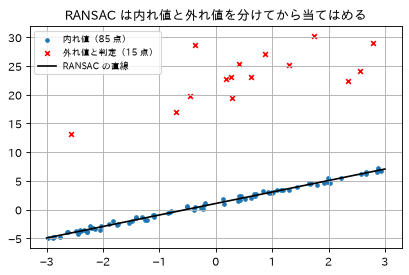

本物の外れ値 15 点を、すべて外れ値と判定: True
本物の内れ値を外れ値と誤判定した数: 0


In [7]:
ransac = models["RANSAC"]
inlier = ransac.inlier_mask_
plt.scatter(x[inlier], y[inlier], s=10, label=f"内れ値（{inlier.sum()} 点）")
plt.scatter(x[~inlier], y[~inlier], s=18, c="red", marker="x", label=f"外れ値と判定（{(~inlier).sum()} 点）")
plt.plot(grid, ransac.predict(grid), c="black", label="RANSAC の直線")
plt.legend(fontsize=8); plt.title("RANSAC は内れ値と外れ値を分けてから当てはめる"); plt.show()

truly_outlier = np.zeros(100, bool); truly_outlier[:15] = True
print("本物の外れ値 15 点を、すべて外れ値と判定:", (~inlier[truly_outlier]).all())
print("本物の内れ値を外れ値と誤判定した数:", (~inlier[~truly_outlier]).sum())

👀 本物の外れ値 15 点を、過不足なく外れ値と判定しました。`inlier_mask_` を使えば、どのデータが怪しいかを**外れ値の検出**として取り出せます。

### 1.1.14.3 Theil-Sen 推定量: 一般化された中央値に基づく推定量

📖 `TheilSenRegressor` は、中央値を多次元に一般化したものを使います。そのため、多変量の外れ値に頑健です。ただし、その頑健さは**問題の次元が上がると急速に低下**し、高次元では頑健性を失って、最小二乗法と変わらなくなります。

**📖 理論的な考察**: Theil-Sen は、漸近的な効率と不偏性の点で最小二乗法と同程度です。最小二乗法と違って**ノンパラメトリック**（データの分布を仮定しない）な手法です。中央値に基づくので、壊れたデータ（外れ値）に頑健です。1 変数の単回帰では、**破綻点は約 29.3%**、つまり約 29.3% までの任意に壊れたデータに耐えられます。

scikit-learn の実装は、空間中央値（中央値の多次元版）を使って多変量線形回帰に一般化したものです。時間・空間の計算量は $\binom{n_\text{samples}}{n_\text{subsamples}}$ に比例するので、サンプル数や特徴数が多い問題に全組み合わせを使うのは現実的ではありません。そこで、部分集団の大きさ（`n_subsamples`）を指定し、組み合わせの一部だけをランダムに使うことで計算量を抑えられます。

> 📚 **用語**
> - **中央値（median）**: 小さい順に並べたときの真ん中の値。極端な値が混ざっても動きにくい（平均は引きずられる）。
> - **ノンパラメトリック**: 「データは正規分布に従う」のような、分布の形の仮定を置かない手法。
> - **漸近的な効率**: サンプル数を十分大きくしたとき、推定のばらつきがどれだけ小さいか。最小二乗法と「同程度」なら、外れ値がないときにも損が少ない。
> - **不偏性**: 何度も推定を繰り返したときの平均が、本当の値に一致すること（系統的な偏りがない）。
> - **空間中央値（spatial median）**: 多次元の点の集まりで、「すべての点までの距離の合計」が最小になる点。中央値の多次元版。

### 🔢 数式を読む

$$\binom{n_\text{samples}}{n_\text{subsamples}}$$

これは**二項係数**で、「$n_\text{samples}$ 個の中から $n_\text{subsamples}$ 個を選ぶ組み合わせの数」です。100 件から 2 件を選ぶなら 4950 通り、1000 件なら約 50 万通り、1000 件から 3 件なら約 1.7 億通りと、急速に増えます。Theil-Sen は、この組み合わせごとに当てはめを行うので計算が重く、`n_subsamples` や `max_subpopulation` で組み合わせの数を制限します。

### 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史（参考情報）

- 🎯 分布の仮定なしに、外れ値に強い傾きを求められます。外れ値がないときの効率も最小二乗法に近いので、「念のため頑健な方法を使っておく」選択として損が小さい方法です。
- 🏭 **気候・水文学の長期トレンド分析**: 気温や降水量が 10 年あたりどれだけ変化したかを求めるときに、「Sen の傾き（Sen's slope）」として、トレンドの有無を調べるマン・ケンドール検定と組み合わせて広く使われています。
- 🕰️ **1950 年**に計量経済学者**タイル（Henri Theil）**が提案し、**1968 年**に統計学者**セン（Pranab K. Sen）**が性質を詳しく調べて広めました。2 人の名前から Theil-Sen 推定量と呼ばれます。

### 💡 補足: Theil-Sen のしくみ（1 変数の場合）

**2 点を結ぶ直線の傾きを、すべての点の組について計算し、その中央値を傾きにする**、というのが元の Theil-Sen 法です。平均ではなく中央値なので、極端な傾きをいくつか含んでいても結果が動きません。

### 🧪 やってみよう: 破綻点「約 29.3%」を確かめる

y 方向の大きな外れ値の割合を増やしていき、傾きの誤差（5 回の平均）を見ます。

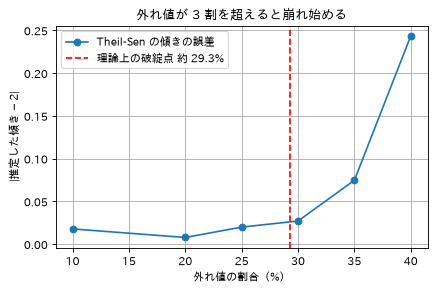

,Theil-Sen の傾きの誤差
外れ値の割合（%）,
10,0.0178
20,0.0078
25,0.0199
30,0.0270
35,0.0747
40,0.2435


In [8]:
breakdown = {}
for frac in [0.1, 0.2, 0.25, 0.3, 0.35, 0.4]:
    errs = []
    for seed in range(5):
        r = np.random.RandomState(seed)
        xs = r.uniform(-2, 2, 200); ys = 2 * xs + 1 + 0.3 * r.randn(200)
        k = int(frac * 200); ys[:k] = r.uniform(15, 30, k)
        errs.append(abs(lm.TheilSenRegressor(random_state=0).fit(xs[:, None], ys).coef_[0] - 2))
    breakdown[int(frac * 100)] = np.mean(errs)
s = pd.Series(breakdown, name="Theil-Sen の傾きの誤差").rename_axis("外れ値の割合（%）")
plt.plot(s.index, s.values, marker="o", label="Theil-Sen の傾きの誤差")
plt.axvline(29.3, color="red", ls="--", label="理論上の破綻点 約 29.3%")
plt.xlabel("外れ値の割合（%）"); plt.ylabel("|推定した傾き − 2|"); plt.legend(); plt.title("外れ値が 3 割を超えると崩れ始める"); plt.show()
s.to_frame()

👀 3 割程度までは誤差がほとんど増えず、それを超えると急に大きくなり始めました。理論値の約 29.3% とおおむね合っています（外れ値の位置がランダムなので、ぴったり 29.3% で崩れるわけではありません）。

### 1.1.14.4 Huber 回帰

📖 `HuberRegressor` は Ridge と違い、`epsilon` で外れ値と判定したサンプルには**線形の損失**（二乗ではなく絶対値の比例）を適用します。あるサンプルの誤差の絶対値がしきい値 `epsilon` 未満なら、そのサンプルは内れ値と判定されます。`TheilSenRegressor` や `RANSACRegressor` と違い、外れ値の影響を**無視するのではなく、小さい重みを与えます**。

**📖 数式（Mathematical details）**: `HuberRegressor` は次の式を最小化します。$\sigma$ はデータのスケールで、係数と同時に推定されます。

$$\min_{w, \sigma} \sum_{i=1}^n \left( \sigma + H_\epsilon\left( \frac{X_i w - y_i}{\sigma} \right) \sigma \right) + \alpha \|w\|_2^2, \qquad H_\epsilon(z) = \begin{cases} z^2 & |z| < \epsilon \\ 2\epsilon|z| - \epsilon^2 & \text{それ以外} \end{cases}$$

95% の統計的効率を得るには、`epsilon` を 1.35 にすることが勧められています（既定値も 1.35）。

**📖 `SGDRegressor(loss="huber")` との違い**

- `HuberRegressor` は**スケール不変**です。`epsilon` を一度決めれば、X や y の単位を変えても（たとえば円から千円へ）同じ頑健さが得られます。`SGDRegressor` では、X や y のスケールを変えたら `epsilon` を設定し直す必要があります。
- `HuberRegressor` は、サンプル数が少ないデータでも効率的に使えます。`SGDRegressor` は同じ頑健さを得るために、学習データを何周もする必要があります。

なお、この推定器は R の Robust Regression の実装とは異なります。R の実装は、残差がしきい値をどれだけ超えたかに応じてサンプルに重みを付ける、重み付き最小二乗法です。

> 📚 **用語**
> - **統計的効率**: 同じデータ量で、どれだけばらつきの小さい推定ができるか。「95% の効率」は、データが本当に正規分布のとき、最小二乗法の 95% の精度を保てるという意味。外れ値への強さと引き換えに失う精度が、わずか 5% で済む。
> - **スケール $\sigma$**: 残差の「ふつうの大きさ」。Huber 回帰は、残差をこれで割ってから `epsilon` と比べる。$\sigma$ もデータから推定するので、単位に依存しない（スケール不変）。

### 🔢 数式を読む

| 記号 | 意味 |
|---|---|
| $X_i w - y_i$ | サンプル $i$ の残差 |
| $\frac{X_i w - y_i}{\sigma}$ | 残差をスケール $\sigma$ で割った値。「ふつうの何倍ずれているか」 |
| $H_\epsilon(z)$ | Huber 損失。$\lvert z \rvert < \epsilon$ なら $z^2$（二乗）、それ以外は $2\epsilon \lvert z \rvert - \epsilon^2$（直線） |
| $\sigma + H_\epsilon(\cdot) \sigma$ | $\sigma$ も同時に推定するための形。$\sigma$ を小さくしすぎたり大きくしすぎたりしないように釣り合いをとる |
| $\alpha \lVert w\rVert _2^2$ | Ridge と同じ L2 正則化 |

**日本語で読むと**: 「ふつうの大きさ」で割った残差が `epsilon` 以内なら二乗で、それを超えたら直線で罰し、全サンプルの合計を最小にする。$2\epsilon|z| - \epsilon^2$ の形は、$|z| = \epsilon$ の地点で二乗の曲線となめらかにつながるように決められています。

### 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史（参考情報）

- 🎯 外れ値を**捨てずに軽く扱う**ので、「外れ値かどうか微妙な点」も含めて全データの情報を使えます。計算も速く、少ないサンプルでも安定します（y 方向の外れ値に限る点は、実験 ② のとおり）。
- 🏭 センサーや計測データの回帰、金融データの回帰など。深層学習でも、物体検出で物体の位置を回帰するときの損失（Smooth L1 損失）として、Huber 損失とほぼ同じ形のものが使われています。
- 🕰️ **1964 年**に統計学者**ピーター・ヒューバー**が、論文 *Robust Estimation of a Location Parameter*（Annals of Mathematical Statistics）で発表しました。この論文は、ロバスト統計学という分野の出発点の 1 つとされています。ガイドの参考文献の教科書 *Robust Statistics* もヒューバーによるものです。

### 💡 補足: 近くは二乗、遠くは直線

Huber 損失は、残差が小さい範囲では二乗誤差（ていねいに合わせる）、大きい範囲では絶対値（外れ値の影響を増やしすぎない）を使う、**いいとこ取り**の損失関数です。

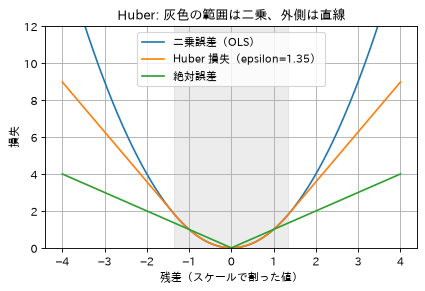

In [9]:
r_ = np.linspace(-4, 4, 200); eps = 1.35
huber = np.where(np.abs(r_) < eps, r_ ** 2, 2 * eps * np.abs(r_) - eps ** 2)
plt.plot(r_, r_ ** 2, label="二乗誤差（OLS）"); plt.plot(r_, huber, label=f"Huber 損失（epsilon={eps}）")
plt.plot(r_, np.abs(r_), label="絶対誤差")
plt.axvspan(-eps, eps, color="gray", alpha=0.15)
plt.ylim(0, 12); plt.xlabel("残差（スケールで割った値）"); plt.ylabel("損失"); plt.legend()
plt.title("Huber: 灰色の範囲は二乗、外側は直線"); plt.show()

### 🧪 やってみよう: スケール不変性を確かめる

目的変数を 100 倍（単位を変えたのと同じ）にして学習し直し、係数が正しく 100 倍になるかを比べます。

In [10]:
rng = np.random.RandomState(0)
X_h = rng.randn(50, 1); y_h = 3 * X_h[:, 0] + rng.randn(50)
rows = {}
for name, make in [("HuberRegressor", lm.HuberRegressor),
                   ("SGDRegressor(loss='huber')", lambda: lm.SGDRegressor(loss="huber", random_state=0))]:
    c1 = make().fit(X_h, y_h).coef_[0]
    c100 = make().fit(X_h, 100 * y_h).coef_[0]
    rows[name] = {"y のままの係数": c1, "y×100 の係数": c100, "比（100 なら正しい）": c100 / c1}
pd.DataFrame(rows).T

,y のままの係数,y×100 の係数,比（100 なら正しい）
HuberRegressor,2.9141,291.3711,99.9864
SGDRegressor(loss='huber'),0.1112,0.1211,1.0898


👀 `HuberRegressor` は、y を 100 倍すると係数もきちんと 100 倍になりました。`SGDRegressor(loss="huber")` は約 1 倍にしかならず、完全に崩れています。SGD 側の `epsilon`（既定 0.1）は y の単位のまま固定なので、y を 100 倍すると**ほぼすべての点が「外れ値扱い」**になってしまうからです。ガイドの説明どおりです。

もう 1 つ注目してほしいのは、`SGDRegressor` は **y のままでも係数が 0.11** で、真の値 3 から大きく外れている点です。サンプルが 50 件しかなく、SGD が十分に学習できていません。これもガイドの 2 点目「少ないサンプルでは `HuberRegressor` のほうが効率的」の実例です。

### 🧪 やってみよう: `outliers_` は外れ値検出に使えるか

`HuberRegressor` には、外れ値と判定したサンプルを示す `outliers_` 属性があります。実験 ① のデータ（本物の外れ値は 15 点）で見てみます。

In [11]:
hub = models["Huber"]
print("Huber が outliers_ で外れ値とした数:", hub.outliers_.sum(), "（本物の外れ値は 15 点）")
print("そのうち本物の外れ値:", hub.outliers_[:15].sum())
print("RANSAC が外れ値とした数:", (~models["RANSAC"].inlier_mask_).sum())

Huber が outliers_ で外れ値とした数: 36 （本物の外れ値は 15 点）
そのうち本物の外れ値: 15
RANSAC が外れ値とした数: 15


> ⚠️ **つまずきポイント（ガイドに書かれていない）**: `HuberRegressor.outliers_` は、本物の外れ値 15 点をすべて含んでいますが、それ以外にも多くのふつうの点を「外れ値」としています。`outliers_` は「`epsilon` の外側にあり、**線形の損失を適用した点**」という意味で、外れ値の検出を目的にしたものではありません。外れ値を取り出したいなら、RANSAC の `inlier_mask_` のほうが向いています。

---
## 2. 分位点回帰（1.1.15 Quantile Regression）

**ねらい**: 「平均」ではなく「上位 10% の値」「中央値」などを予測し、予測区間を作れるようになる。

### 💡 補足: 分位点とは

データを小さい順に並べたとき、下から 10% の位置の値を **10% 分位点**（0.1 分位点）、真ん中を**中央値**（0.5 分位点）、下から 90% を **90% 分位点**と呼びます。

たとえばタクシーの到着時間を予測するとき、「平均 8 分」よりも「**9 割の確率で 12 分以内**」のほうが役に立つ場面があります。これが 0.9 分位点の予測です。

### 📖 ガイドの解説

分位点回帰は、$X$ を条件とした $y$ の**中央値やその他の分位点**を推定します。最小二乗法は条件付き**平均**を推定します。

点予測ではなく**区間**を予測したいときに役立ちます。予測区間は、予測誤差が「平均 0・分散一定の正規分布に従う」と仮定して計算されることがあります。分位点回帰なら、誤差の分散が一定でない（ただし予測できる）場合や、正規分布でない場合でも、妥当な予測区間が得られます。

**ピンボール損失**の最小化に基づけば、線形モデル以外でも条件付き分位点を推定できます。たとえば `GradientBoostingRegressor` は、`loss="quantile"` にして `alpha` に予測したい分位点を指定すれば、条件付き分位点を予測できます（ガイドの例「Prediction Intervals for Gradient Boosting Regression」）。

分位点回帰の多くの実装は線形計画問題に基づいており、scikit-learn の実装は `scipy.optimize.linprog` を使います。

**📖 数式（Mathematical details）**: `QuantileRegressor` は、$q$ 分位点（$q \in (0, 1)$）の線形予測 $\hat{y}(w, X) = Xw$ を行います。係数 $w$ は次の最小化問題の解です。

$$\min_{w} \frac{1}{n_\text{samples}} \sum_i PB_q(y_i - X_i w) + \alpha \|w\|_1$$

$PB_q$ は**ピンボール損失**（線形損失とも呼ぶ。`mean_pinball_loss` も参照）で、$\alpha$ は Lasso と同様の L1 正則化です。

$$PB_q(t) = q \max(t, 0) + (1 - q) \max(-t, 0) = \begin{cases} q t & t > 0 \\ 0 & t = 0 \\ (q - 1) t & t < 0 \end{cases}$$

ピンボール損失は残差に対して線形なだけなので、分位点回帰は二乗誤差に基づく平均の推定より、**外れ値にずっと頑健**です。その中間にあるのが `HuberRegressor` です。

> 📚 **用語**
> - **条件付き平均 / 条件付き分位点**: 「$X$ がこの値のとき」の $y$ の平均 / 分位点。回帰は、$X$ ごとにこれを予測する。
> - **予測区間**: 「新しい観測値がこの範囲に入る確率が 80%」のような、予測の幅。
> - **不均一分散（heteroscedasticity）**: 誤差のばらつきが、$X$ によって変わること（実験のデータがこれ）。
> - **線形計画問題**: 一次式の制約のもとで、一次式を最小（最大）にする最適化問題。ピンボール損失は直線の組み合わせなので、この形に書き直して効率よく解ける。
> - **L1 正則化**: 1/4 の Lasso と同じ、係数の絶対値の合計による罰。

### 🔢 数式を読む

| 記号 | 意味 |
|---|---|
| $q$ | 予測したい分位点（0.9 なら 90% 分位点）。`quantile` 引数 |
| $t = y_i - X_i w$ | 残差（実際 − 予測）。正なら予測が低すぎ、負なら高すぎ |
| $PB_q(t)$ | $t > 0$（低すぎ）なら $q \cdot t$、$t < 0$（高すぎ）なら $(1 - q) \cdot \lvert t \rvert$ の罰 |
| $\alpha \lVert w\rVert _1$ | Lasso と同じ L1 正則化。`alpha`（既定 1.0） |

**日本語で読むと**: 予測が低すぎたときは $q$ の重さで、高すぎたときは $1 - q$ の重さで罰を与え、その平均を最小にする。$q = 0.5$ なら上下同じ重さなので、残差の絶対値の平均を最小にすることになり、**中央値**を予測する。

### 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史（参考情報）

- 🎯 「平均的にはいくつか」ではなく、「**最悪のケースに近いといくつか**」「**ほぼ確実にこの範囲**」を知りたいとき。ばらつき方が一定でないデータでも、その場所に合った幅の予測区間が得られます。
- 🏭 配送や到着の予想時間（「9 割はこの時間以内」）、電力・需要の予測で上振れに備えた計画、金融のリスク管理（損失の分位点を見る **VaR**、バリュー・アット・リスク）、経済学での賃金の分布の分析（高所得層と低所得層で要因の効き方が違うか）など。
- 🕰️ **1978 年**に計量経済学者**ロジャー・コーエンカーとギルバート・バセット**が、論文 *Regression Quantiles*（Econometrica、ガイドの参考文献）で提案しました。コーエンカーの教科書 *Quantile Regression*（2005 年）も、ガイドの参考文献に挙がっています。

### 💡 補足: ピンボール損失は「非対称な罰」

$q = 0.9$ のとき、予測が実際の値を**下回る**（実際 > 予測）と罰は $0.9 \times$ 差、**上回る**と $0.1 \times$ 差です。下回ることを 9 倍重く罰するので、モデルは「9 割の点が自分より下に来る」高めの位置に予測を置くようになります。

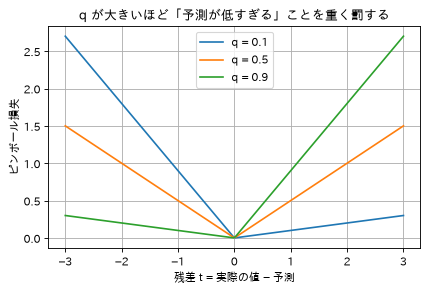

In [12]:
t = np.linspace(-3, 3, 200)
for q in [0.1, 0.5, 0.9]:
    plt.plot(t, np.where(t > 0, q * t, (q - 1) * t), label=f"q = {q}")
plt.xlabel("残差 t = 実際の値 − 予測"); plt.ylabel("ピンボール損失"); plt.legend()
plt.title("q が大きいほど「予測が低すぎる」ことを重く罰する"); plt.show()

### 🧪 やってみよう: ばらつきが x とともに広がるデータで予測区間を作る

x が大きいほどばらつきが大きくなるデータ（分散が一定でない）を作り、0.1・0.5・0.9 分位点を予測します。比較のため、最小二乗法 + 「平均 ± 一定の幅」の区間も作ります。

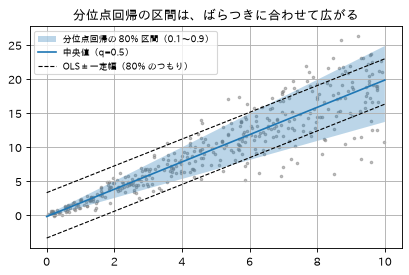

In [13]:
rng = np.random.RandomState(0)
xq = rng.uniform(0, 10, 400)
yq = 2 * xq + rng.randn(400) * (0.2 + 0.4 * xq)          # x に比例してばらつきが大きくなる
Xq = xq[:, None]

qmodels = {q: lm.QuantileRegressor(quantile=q, alpha=0).fit(Xq, yq) for q in [0.1, 0.5, 0.9]}

# 比較: OLS の予測 ± 残差の標準偏差 × 1.28（正規分布なら 80% 区間）
ols_q = lm.LinearRegression().fit(Xq, yq)
half = 1.28 * np.std(yq - ols_q.predict(Xq))

g = np.linspace(0, 10, 50)[:, None]
plt.scatter(xq, yq, s=5, c="gray", alpha=0.5)
plt.fill_between(g[:, 0], qmodels[0.1].predict(g), qmodels[0.9].predict(g), alpha=0.3, label="分位点回帰の 80% 区間（0.1〜0.9）")
plt.plot(g, qmodels[0.5].predict(g), label="中央値（q=0.5）")
plt.plot(g, ols_q.predict(g) - half, "k--", lw=1, label="OLS ± 一定幅（80% のつもり）")
plt.plot(g, ols_q.predict(g) + half, "k--", lw=1)
plt.legend(fontsize=8); plt.title("分位点回帰の区間は、ばらつきに合わせて広がる"); plt.show()

In [14]:
lo, hi = qmodels[0.1].predict(Xq), qmodels[0.9].predict(Xq)
ols_lo, ols_hi = ols_q.predict(Xq) - half, ols_q.predict(Xq) + half
rows = {}
for label, mask in [("x < 3（ばらつき小）", xq < 3), ("3 ≤ x < 7", (xq >= 3) & (xq < 7)), ("x ≥ 7（ばらつき大）", xq >= 7), ("全体", xq >= 0)]:
    rows[label] = {"分位点回帰の区間に入った割合": ((yq >= lo) & (yq <= hi))[mask].mean(),
                   "OLS ± 一定幅に入った割合": ((yq >= ols_lo) & (yq <= ols_hi))[mask].mean()}
print("各分位点の予測を下回った点の割合:",
      {q: round(float((yq < m.predict(Xq)).mean()), 3) for q, m in qmodels.items()})
pd.DataFrame(rows).T.rename_axis("目標は 80%")

各分位点の予測を下回った点の割合: {0.1: 0.098, 0.5: 0.497, 0.9: 0.897}


,分位点回帰の区間に入った割合,OLS ± 一定幅に入った割合
目標は 80%,,
x < 3（ばらつき小）,0.8031,1.0000
3 ≤ x < 7,0.8210,0.8642
x ≥ 7（ばらつき大）,0.7748,0.6036
全体,0.8025,0.8350


### 👀 結果の読み方

- 各分位点 $q$ について、「予測を下回った点の割合」がほぼ $q$ になりました。分位点回帰が狙いどおりに働いています。
- **全体**で見ると、どちらの区間もほぼ 80% の点を含みます。しかし**場所ごと**に見ると違いがはっきりします。
  - OLS ± 一定幅は、ばらつきの小さい x < 3 では**広すぎ**（ほぼ 100%）、ばらつきの大きい x ≥ 7 では**狭すぎ**ます（80% を大きく下回る）。
  - 分位点回帰の区間は、どの場所でも 80% 前後を保っています。

「誤差の分散が一定でなくても妥当な予測区間が得られる」というガイドの説明を、数字で確かめられました。

> ⚠️ **つまずきポイント**: `QuantileRegressor` の `alpha` の**既定値は 1.0**（L1 正則化あり）です。正則化をかけたくないときは、上のように `alpha=0` を明示します。下のセルで、既定値のままだと傾きが大きく縮むことを確かめます。

In [15]:
print("alpha=0   の傾き:", qmodels[0.5].coef_[0].round(3))
print("既定 (alpha=1.0) の傾き:", lm.QuantileRegressor(quantile=0.5).fit(Xq, yq).coef_[0].round(3))

alpha=0   の傾き: 2.002
既定 (alpha=1.0) の傾き: 0.901


---
## 3. 多項式回帰（1.1.16 Polynomial regression: extending linear models with basis functions）

**ねらい**: 「線形モデル」で曲線を当てはめられる理由を理解し、次数の選びすぎに注意できるようになる。

### 📖 ガイドの解説

機械学習でよく使うパターンの 1 つが、**データを非線形な関数で変換してから線形モデルを学習する**ことです。線形手法の速さを保ったまま、ずっと幅広いデータに当てはめられます。

**📖 数式での説明（Mathematical details）**: たとえば 2 次元のデータに対する普通の線形回帰は、次のような平面のモデルです。

$$\hat{y}(w, x) = w_0 + w_1 x_1 + w_2 x_2$$

平面ではなく放物面を当てはめたければ、特徴を 2 次の多項式に組み合わせます。

$$\hat{y}(w, x) = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1 x_2 + w_4 x_1^2 + w_5 x_2^2$$

（ときに驚かれますが）これも**線形モデル**のままです。新しい特徴 $z = [x_1, x_2, x_1 x_2, x_1^2, x_2^2]$ を作ったと考えれば、

$$\hat{y}(w, z) = w_0 + w_1 z_1 + w_2 z_2 + w_3 z_3 + w_4 z_4 + w_5 z_5$$

と書け、$w$ について線形なので、これまでと同じ方法で解けます。こうした**基底関数**で作った高次元の空間で線形に当てはめることで、モデルはずっと柔軟になります。

> 📚 **用語**
> - **基底関数（basis function）**: 元の特徴から新しい特徴を作る関数（$x^2$、$x_1 x_2$、$\sin x$ など）。これらの重み付き和で、複雑な関数を組み立てる。
> - **多項式 / 次数**: $3 - 2x + x^2 - x^3$ のような、累乗の和の式。いちばん大きい累乗の数（ここでは 3）が次数。
> - **放物面**: 放物線（$y = x^2$）を 2 次元に広げた、お椀の形の曲面。
> - **交互作用（interaction）**: 2 つの特徴の組み合わせによって生まれる効果。「価格の効果が季節によって違う」なら、価格と季節の間に交互作用がある。

### 🔢 数式を読む

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1 x_2 + w_4 x_1^2 + w_5 x_2^2$$

| 項 | 意味 |
|---|---|
| $w_1 x_1 + w_2 x_2$ | 元の特徴の効果（平面） |
| $w_3 x_1 x_2$ | 交互作用。$x_1$ の効果の大きさが $x_2$ によって変わる |
| $w_4 x_1^2 + w_5 x_2^2$ | 曲がり。値が大きくなると効果が加速したり、頭打ちになったりする |

**日本語で読むと**: 特徴の二乗や掛け算を「新しい特徴」として加え、それぞれに係数を付けて足し合わせる。係数 $w$ について見れば、足し算の形のままなので線形モデル。

### 🎯 なぜ使うのか / 🏭 利用例 / 🕰️ 歴史（参考情報）

- 🎯 線形モデルの**速さ・解釈しやすさ・解きやすさ**（1/4〜3/4 で学んだ手法がすべて使える）を保ったまま、曲がった関係や交互作用を表せます。
- 🏭 物理・化学の**校正曲線**（温度とセンサー出力の関係を 2〜3 次式で表す）、薬の用量と効果の関係、マーケティングで「価格 × キャンペーンの有無」のような交互作用を調べる分析など。
- 🕰️ 多項式による当てはめは、最小二乗法とほぼ同じくらい古い歴史を持ちます。一方、「特徴を非線形に変換してから線形モデルを使う」考え方を突き詰めると、変換後の特徴を明示的に作らずに計算する**カーネル法**に行き着きます。これが次の **1.3 カーネルリッジ回帰**のテーマです。

### 💡 補足: 「線形」とは何について線形なのか

「線形モデル」の「線形」は、**係数 $w$ について線形**（係数を掛けて足すだけ）という意味です。特徴 $x$ について線形である必要はありません。$x^2$ や $x_1 x_2$ を**新しい特徴として追加**すれば、曲線や曲面も表せます。

> 🧩 **プログラマ向けの見方**: モデル本体（`LinearRegression`）は何も変えず、入力を**前処理で変換する**だけで表現力を上げています。「変換（Transformer）」と「予測（Predictor）」を分けて組み合わせる設計の典型例です。

### 🧪 やってみよう: ガイドのコード例（PolynomialFeatures）

In [16]:
X_p = np.arange(6).reshape(3, 2)
print("元の X:\n", X_p)
poly = PolynomialFeatures(degree=2)
X_p2 = poly.fit_transform(X_p)
print("変換後:\n", X_p2)
print("各列の意味:", poly.get_feature_names_out(["x1", "x2"]))
assert np.array_equal(X_p2, [[1, 0, 1, 0, 0, 1], [1, 2, 3, 4, 6, 9], [1, 4, 5, 16, 20, 25]])  # ガイドの出力と一致

元の X:
 [[0 1]
 [2 3]
 [4 5]]
変換後:
 [[ 1.  0.  1.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.]
 [ 1.  4.  5. 16. 20. 25.]]
各列の意味: ['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


👀 $[x_1, x_2]$ が $[1, x_1, x_2, x_1^2, x_1 x_2, x_2^2]$ に変換されました。`get_feature_names_out` で各列の意味を確かめられます。

📖 この前処理は `Pipeline` でまとめられます。多項式回帰を 1 つのオブジェクトとして作り、使えます。

In [17]:
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', lm.LinearRegression(fit_intercept=False))])
x_c = np.arange(5)
y_c = 3 - 2 * x_c + x_c ** 2 - x_c ** 3            # 3 次多項式のデータ
model = model.fit(x_c[:, np.newaxis], y_c)
print("学習した係数:", model.named_steps['linear'].coef_)
assert np.allclose(model.named_steps['linear'].coef_, [3, -2, 1, -1])   # ガイドの出力と一致

学習した係数: [ 3. -2.  1. -1.]


👀 多項式特徴で学習した線形モデルが、元の多項式の係数 $3 - 2x + x^2 - x^3$ を**正確に復元**しました。

💡 `fit_intercept=False` にしているのは、`PolynomialFeatures` がすでに定数列（1 の列）を作っているからです。切片を二重に持たないようにしています。

### 🧪 やってみよう: 次数を上げすぎるとどうなるか

sin 曲線にノイズを加えた 30 点に、次数 1・3・15 の多項式を当てはめます。

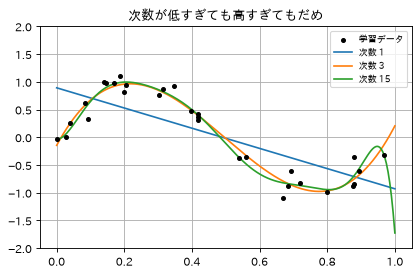

,学習データの誤差,テストデータの誤差
次数 1,0.2033,0.2570
次数 3,0.0234,0.0496
次数 15,0.0184,0.0682


In [18]:
rng = np.random.RandomState(1)
xs = np.sort(rng.uniform(0, 1, 30)); ys = np.sin(2 * np.pi * xs) + 0.2 * rng.randn(30)
x_test = rng.uniform(0, 1, 200); y_test2 = np.sin(2 * np.pi * x_test) + 0.2 * rng.randn(200)
g = np.linspace(0, 1, 200)[:, None]

plt.scatter(xs, ys, s=12, c="black", zorder=3, label="学習データ")
rows = {}
for d in [1, 3, 15]:
    m = make_pipeline(PolynomialFeatures(degree=d), lm.LinearRegression()).fit(xs[:, None], ys)
    plt.plot(g, m.predict(g), label=f"次数 {d}")
    rows[f"次数 {d}"] = {"学習データの誤差": np.mean((m.predict(xs[:, None]) - ys) ** 2),
                         "テストデータの誤差": np.mean((m.predict(x_test[:, None]) - y_test2) ** 2)}
plt.ylim(-2, 2); plt.legend(fontsize=8); plt.title("次数が低すぎても高すぎてもだめ"); plt.show()
pd.DataFrame(rows).T

### 👀 結果の読み方

- **次数 1**（直線）: 曲線を表せず、学習データにもテストデータにも合わない（**未学習・アンダーフィット**）。
- **次数 3**: 学習データにもテストデータにもよく合う。
- **次数 15**: 学習データの誤差はいちばん小さいのに、グラフは端で暴れ、テストデータの誤差は大きくなる（**過学習・オーバーフィット**）。

> ⚠️ **つまずきポイント**: 学習データでの誤差だけを見ていると、次数を上げるほど「良くなった」ように見えます。**見ていないデータ**での誤差で比べる必要があります（交差検証、3 章）。次数を上げすぎるときは、1/4 の Ridge などの正則化を組み合わせるのも有効です。

### 📖 交互作用項だけを使う（interaction_only）

状況によっては、1 つの特徴の高い累乗（$x_1^2$ など）は要らず、**最大 $d$ 個の異なる特徴の積**（交互作用項）だけが欲しいことがあります。`PolynomialFeatures` で `interaction_only=True` を指定すると得られます。

たとえばブール値（0 / 1）の特徴では、どんな $n$ でも $x_i^n = x_i$ なので累乗は無意味です。一方、$x_i x_j$ は 2 つのブール値の**論理積（AND）**を表します。これを使うと、**XOR 問題を線形分類器で解けます**。

### 💡 補足: XOR 問題

XOR（排他的論理和）は、「2 つの入力のうち**片方だけ**が 1 なら 1」という関数です。4 点を平面に置くと、1 のクラスが対角に並ぶので、**1 本の直線ではどうしても分けられません**（線形分離不可能）。ところが $x_1 x_2$ という特徴を足して 3 次元にすると、平面で分けられるようになります。

In [19]:
X_x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_x = X_x[:, 0] ^ X_x[:, 1]
print("XOR の正解:", y_x)

clf_plain = lm.Perceptron(max_iter=10, tol=None, shuffle=False).fit(X_x, y_x)
print("そのままの特徴での正解率:", clf_plain.score(X_x, y_x))

X_x2 = PolynomialFeatures(interaction_only=True).fit_transform(X_x).astype(int)
print("交互作用項を追加した X（列: 1, x1, x2, x1·x2）:\n", X_x2)
clf = lm.Perceptron(fit_intercept=False, max_iter=10, tol=None, shuffle=False).fit(X_x2, y_x)
print("予測:", clf.predict(X_x2), "/ 正解率:", clf.score(X_x2, y_x))
assert (clf.predict(X_x2) == [0, 1, 1, 0]).all() and clf.score(X_x2, y_x) == 1.0   # ガイドの出力と一致

XOR の正解: [0 1 1 0]
そのままの特徴での正解率: 0.5
交互作用項を追加した X（列: 1, x1, x2, x1·x2）:
 [[1 0 0 0]
 [1 0 1 0]
 [1 1 0 0]
 [1 1 1 1]]
予測: [0 1 1 0] / 正解率: 1.0


👀 元の 2 つの特徴だけでは正解率 50% どまりでしたが、$x_1 x_2$ の列を足しただけで**正解率 100%** になりました。モデル（パーセプトロン）は同じ線形分類器のままです。

---
## 4. 1.1 線形モデル全体のまとめ

### このノートの比較表

| 手法 | 強い状況 | 弱い状況 | メモ |
|---|---|---|---|
| `RANSACRegressor` | y 方向の大きな外れ値、X 方向の外れ値 | 小さな外れ値がたくさん | 迷ったらこれ。`inlier_mask_` で外れ値を検出できる |
| `TheilSenRegressor` | X 方向・y 方向の外れ値（〜約 3 割） | 高次元、サンプル数が多い（遅い） | 中央値ベースでノンパラメトリック |
| `HuberRegressor` | y 方向の外れ値 | **X 方向の外れ値（高レバレッジ点）** | 速い、スケール不変。外れ値を無視せず軽く扱う |
| `QuantileRegressor` | 分位点・予測区間が欲しい | — | `alpha` の既定は 1.0 |
| `PolynomialFeatures` + 線形モデル | 曲線的な関係 | 次数が高すぎると過学習 | `Pipeline` で 1 つのモデルにできる |

### 1.1 全体: どの線形モデルを選ぶか

| やりたいこと | まず試すもの | ノート |
|---|---|---|
| 数値を予測したい（基本） | `LinearRegression` → 特徴が多い・相関が強いなら `RidgeCV` | 1/4 |
| 効く特徴を選びたい | `LassoCV`、個数を決めたいなら `OrthogonalMatchingPursuit` | 1/4, 2/4 |
| 相関する特徴をまとめて残したい | `ElasticNetCV` | 1/4 |
| 複数の目的変数で同じ特徴を使いたい | `MultiTaskLassoCV` / `MultiTaskElasticNetCV` | 1/4 |
| 予測の不確かさも欲しい | `BayesianRidge`（`return_std=True`） | 2/4 |
| クラスを予測したい | `LogisticRegression`（多クラス・スパースなら `saga`） | 3/4 |
| 件数・正の金額を予測したい | `PoissonRegressor` / `GammaRegressor` / `TweedieRegressor` | 3/4 |
| データが大きい・逐次届く | `SGDClassifier` / `SGDRegressor`（`partial_fit`, `average=True`） | 3/4 |
| 外れ値がある | `RANSACRegressor`（y 方向の小さな外れ値なら `HuberRegressor`） | 4/4 |
| 予測区間が欲しい | `QuantileRegressor` | 4/4 |
| 曲線を当てはめたい | `PolynomialFeatures` + 線形モデル（+ 正則化） | 4/4 |

### 🧩 ドメインモデルの視点（1.1 全体）

- 1.1 に登場した数十のクラスは、すべて「`fit(X, y)` で学習し、`coef_` / `intercept_` を持ち、`predict(X)` で予測する」という**同じ契約**に従っていました。そのおかげで、比較実験はモデル名を差し替えるだけで書けました。
- `RANSACRegressor` は内部に別の推定器（`estimator_`）を持ち、`make_pipeline(PolynomialFeatures(3), TheilSenRegressor())` は**変換と予測を合成したもの自体が推定器**になっていました。「Estimator を部品として組み立てる」設計は、8.1 節（Pipeline）と 3.2 節（GridSearchCV）で本格的に学びます。
- 一方で、`RANSACRegressor` だけ係数が `estimator_.coef_` にある、`RidgeClassifier.coef_` の形が違う、`HuberRegressor.outliers_` の意味が名前から想像するものと違う、など**契約の細部はそろっていない**ことも分かりました。

### ✅ 確認クイズ

**Q1.** 面積 5000 m² の物件（入力ミス）が数件混ざった家賃データで回帰したい。Huber と RANSAC のどちらを選びますか。

<details><summary>答え</summary>

RANSAC（または Theil-Sen）。これは X 方向の外れ値（高レバレッジ点）なので、残差で外れ値を判定する Huber は見抜けません。
</details>

**Q2.** `HuberRegressor` と `SGDRegressor(loss="huber")` で、目的変数の単位を円から千円に変えたとき、設定し直しが必要なのはどちらですか。

<details><summary>答え</summary>

`SGDRegressor`。`HuberRegressor` はスケールも同時に推定するのでスケール不変です。
</details>

**Q3.** 「9 割の注文は何分以内に届くか」を予測したい。どう指定しますか。

<details><summary>答え</summary>

`QuantileRegressor(quantile=0.9, alpha=0)`（正則化が不要なら `alpha=0` を明示）。
</details>

**Q4.** $y = w_0 + w_1 x + w_2 x^2$ は線形モデルですか。

<details><summary>答え</summary>

線形モデルです。係数 $w$ について線形だからです。$x^2$ を新しい特徴として加えた線形回帰として解けます。
</details>

---
**前のノート**: [3/4 分類と一般化線形モデル](./01_linear_models_3_classification_glm.ipynb) ・ **最初に戻る**: [1/4 最小二乗法と正則化](./01_linear_models_1_ols_regularization.ipynb)

**次の節**: [1.2 線形判別分析と二次判別分析](./02_lda_qda.ipynb)